<a href="https://colab.research.google.com/github/JunalChowdhuryG/FIPS-204-Experimentos/blob/main/ML_DSA_Experimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resultados Experimentales y Análisis Comparativo de ML-DSA (FIPS 204)
### Implementación Práctica y Evaluación frente a Otros Esquemas Criptográficos

**Autor:** Chowdhury Gomez, Junal Johir — 20200092K  
**Curso:** CC411A — Seguridad en Sistemas Informáticos  
**Universidad Nacional de Ingeniería**

Este cuaderno contiene el código completo de los tres experimentos reportados en el paper:

1. **Experimento 1** — Benchmarking de rendimiento (Keygen / Sign / Verify)
2. **Experimento 2** — Tamaños de clave y firma (factor de expansión)
3. **Experimento 3** — Caso de uso: distribución de software firmado (firma individual vs. manifiesto) + sensibilidad a la corrupción

Los esquemas comparados son: **ML-DSA-44/65/87**, **Falcon-512/1024**, **SPHINCS+-128s** (todos vía `pqcrypto`), y **RSA-2048/3072**, **ECDSA-P256** (vía `cryptography`).


## 0. Preparación del entorno

Instalación de dependencias (ejecutar solo una vez).


In [ ]:
!pip install pqcrypto cryptography matplotlib --break-system-packages

In [ ]:

import time
import json
import hashlib
import os
import random
import statistics as st

import matplotlib.pyplot as plt
import numpy as np

from pqcrypto.sign import ml_dsa_44, ml_dsa_65, ml_dsa_87
from pqcrypto.sign import falcon_512, falcon_1024
from pqcrypto.sign import sphincs_sha2_128s_simple as sphincs128s

from cryptography.hazmat.primitives.asymmetric import rsa, ec, padding
from cryptography.hazmat.primitives import hashes, serialization

random.seed(42)
print("Entorno listo.")


Entorno listo.


---
## 1. Experimento 1: Benchmarking de Rendimiento (Keygen / Sign / Verify)

**Pregunta de investigación:** ¿Cuál es el costo computacional real de ML-DSA frente a otros
esquemas post-cuánticos y clásicos, y cómo varía entre sus distintos niveles de seguridad?

**Diseño:** Se mide el tiempo de Keygen (N=20), Sign (N=100) y Verify (N=200) para cada esquema,
usando un mensaje fijo de 32 bytes. Se reportan media, desviación estándar, mínimo y máximo.


In [ ]:
MSG = b"x" * 32  # mensaje fijo de 32 bytes

N_KEYGEN = 20
N_SIGN = 100
N_VERIFY = 200


def timeit(fn, n):
    """Ejecuta fn() n veces (descartando la primera) y retorna lista de tiempos en ms."""
    fn()  # warm-up / descarte de primera iteración
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        fn()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)
    return times


def summarize(times):
    return {
        "mean_ms": round(st.mean(times), 4),
        "stdev_ms": round(st.stdev(times), 4) if len(times) > 1 else 0.0,
        "min_ms": round(min(times), 4),
        "max_ms": round(max(times), 4),
    }


In [ ]:
def bench_pqc(name, mod):
    result = {"scheme": name}

    kg_times = timeit(lambda: mod.generate_keypair(), N_KEYGEN)
    result["keygen"] = summarize(kg_times)

    pk, sk = mod.generate_keypair()

    sign_times = timeit(lambda: mod.sign(sk, MSG), N_SIGN)
    result["sign"] = summarize(sign_times)

    sig = mod.sign(sk, MSG)
    verify_times = timeit(lambda: mod.verify(pk, MSG, sig), N_VERIFY)
    result["verify"] = summarize(verify_times)

    result["sizes_bytes"] = {
        "public_key": len(pk),
        "secret_key": len(sk),
        "signature": len(sig),
    }
    return result


def bench_rsa(name, key_size):
    result = {"scheme": name}

    def keygen():
        return rsa.generate_private_key(public_exponent=65537, key_size=key_size)

    kg_times = timeit(keygen, N_KEYGEN)
    result["keygen"] = summarize(kg_times)

    priv = keygen()
    pub = priv.public_key()

    def sign():
        return priv.sign(
            MSG,
            padding.PSS(mgf=padding.MGF1(hashes.SHA256()), salt_length=padding.PSS.MAX_LENGTH),
            hashes.SHA256(),
        )

    sign_times = timeit(sign, N_SIGN)
    result["sign"] = summarize(sign_times)

    sig = sign()

    def verify():
        pub.verify(
            sig, MSG,
            padding.PSS(mgf=padding.MGF1(hashes.SHA256()), salt_length=padding.PSS.MAX_LENGTH),
            hashes.SHA256(),
        )
        return True

    verify_times = timeit(verify, N_VERIFY)
    result["verify"] = summarize(verify_times)

    pk_bytes = pub.public_bytes(serialization.Encoding.DER, serialization.PublicFormat.SubjectPublicKeyInfo)
    sk_bytes = priv.private_bytes(
        serialization.Encoding.DER, serialization.PrivateFormat.PKCS8, serialization.NoEncryption()
    )
    result["sizes_bytes"] = {
        "public_key": len(pk_bytes),
        "secret_key": len(sk_bytes),
        "signature": len(sig),
    }
    return result


def bench_ecdsa():
    result = {"scheme": "ECDSA-P256"}

    def keygen():
        return ec.generate_private_key(ec.SECP256R1())

    kg_times = timeit(keygen, N_KEYGEN)
    result["keygen"] = summarize(kg_times)

    priv = keygen()
    pub = priv.public_key()

    def sign():
        return priv.sign(MSG, ec.ECDSA(hashes.SHA256()))

    sign_times = timeit(sign, N_SIGN)
    result["sign"] = summarize(sign_times)

    sig = sign()

    def verify():
        pub.verify(sig, MSG, ec.ECDSA(hashes.SHA256()))
        return True

    verify_times = timeit(verify, N_VERIFY)
    result["verify"] = summarize(verify_times)

    pk_bytes = pub.public_bytes(serialization.Encoding.DER, serialization.PublicFormat.SubjectPublicKeyInfo)
    sk_bytes = priv.private_bytes(
        serialization.Encoding.DER, serialization.PrivateFormat.PKCS8, serialization.NoEncryption()
    )
    result["sizes_bytes"] = {
        "public_key": len(pk_bytes),
        "secret_key": len(sk_bytes),
        "signature": len(sig),
    }
    return result


### Ejecución del Experimento 1

**Nota:** SPHINCS+-128s esta celda puede tardar
2-3 minutos


In [ ]:
results_exp1 = []

pqc_schemes = [
    ("ML-DSA-44", ml_dsa_44),
    ("ML-DSA-65", ml_dsa_65),
    ("ML-DSA-87", ml_dsa_87),
    ("Falcon-512", falcon_512),
    ("Falcon-1024", falcon_1024),
    ("SPHINCS+-128s", sphincs128s),
]

for name, mod in pqc_schemes:
    print(f"Ejecutando benchmark: {name} ...")
    results_exp1.append(bench_pqc(name, mod))

print("Ejecutando benchmark: RSA-2048 ...")
results_exp1.append(bench_rsa("RSA-2048", 2048))

print("Ejecutando benchmark: RSA-3072 ...")
results_exp1.append(bench_rsa("RSA-3072", 3072))

print("Ejecutando benchmark: ECDSA-P256 ...")
results_exp1.append(bench_ecdsa())

with open("exp1_resultados.json", "w") as f:
    json.dump(results_exp1, f, indent=2)

print("\nListo. Resultados guardados en exp1_resultados.json")


Ejecutando benchmark: ML-DSA-44 ...
Ejecutando benchmark: ML-DSA-65 ...
Ejecutando benchmark: ML-DSA-87 ...
Ejecutando benchmark: Falcon-512 ...
Ejecutando benchmark: Falcon-1024 ...
Ejecutando benchmark: SPHINCS+-128s ...
Ejecutando benchmark: RSA-2048 ...
Ejecutando benchmark: RSA-3072 ...
Ejecutando benchmark: ECDSA-P256 ...

Listo. Resultados guardados en exp1_resultados.json


In [ ]:
# Tabla resumen
print(f"{'Esquema':<15}{'Keygen(ms)':>12}{'Sign(ms)':>12}{'±std':>8}{'Verify(ms)':>12}")
for r in results_exp1:
    print(f"{r['scheme']:<15}{r['keygen']['mean_ms']:>12.4f}{r['sign']['mean_ms']:>12.4f}"
          f"{r['sign']['stdev_ms']:>8.4f}{r['verify']['mean_ms']:>12.4f}")


Esquema          Keygen(ms)    Sign(ms)    ±std  Verify(ms)
ML-DSA-44            0.4955      0.7805  0.4789      0.2886
ML-DSA-65            0.6787      1.4628  1.1059      0.3179
ML-DSA-87            0.4950      1.6763  0.9152      0.6412
Falcon-512          40.0958     13.4247  5.3185      0.4070
Falcon-1024        315.8945     18.6822  2.5296      0.1472
SPHINCS+-128s      180.8713   1567.5226359.3666      1.3839
RSA-2048            78.0347      1.2537  0.3619      0.0487
RSA-3072           332.7691      3.6991  0.8307      0.0865
ECDSA-P256           0.0279      0.0476  0.0048      0.1255


### Gráficos del Experimento 1

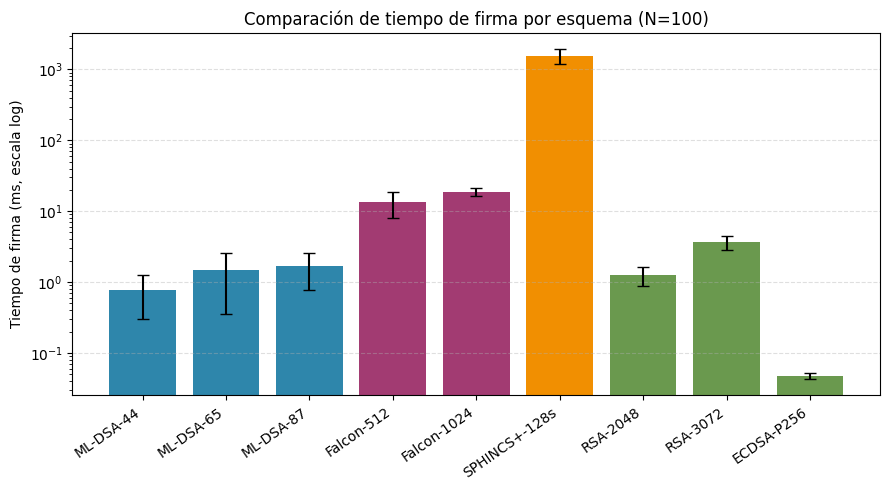

In [ ]:
schemes = [d["scheme"] for d in results_exp1]
sign_means = [d["sign"]["mean_ms"] for d in results_exp1]
sign_std = [d["sign"]["stdev_ms"] for d in results_exp1]
verify_means = [d["verify"]["mean_ms"] for d in results_exp1]
keygen_means = [d["keygen"]["mean_ms"] for d in results_exp1]

colors = ["#2E86AB" if "ML-DSA" in s else "#A23B72" if "Falcon" in s else
          "#F18F01" if "SPHINCS" in s else "#6A994E" for s in schemes]

x = np.arange(len(schemes))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, sign_means, yerr=sign_std, capsize=4, color=colors)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(schemes, rotation=35, ha="right")
ax.set_ylabel("Tiempo de firma (ms, escala log)")
ax.set_title("Comparación de tiempo de firma por esquema (N=100)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


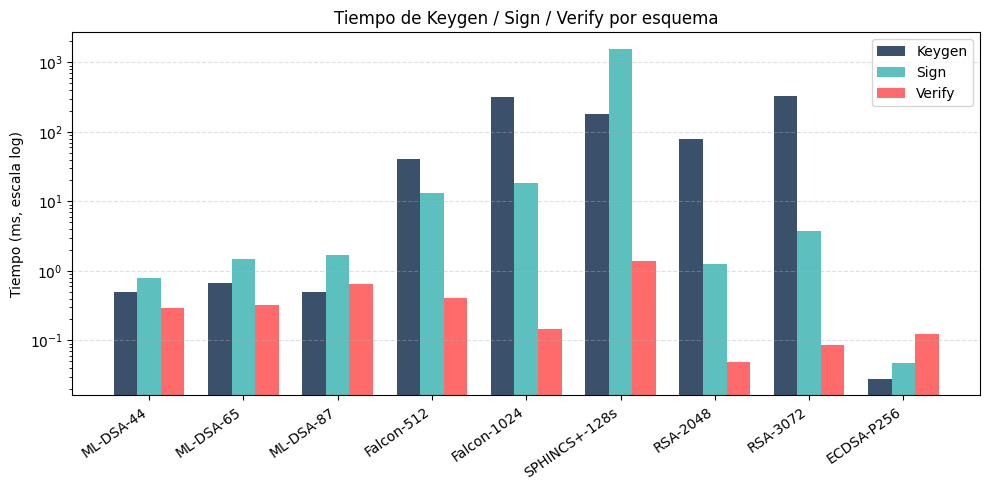

In [ ]:
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, keygen_means, width, label="Keygen", color="#3A506B")
ax.bar(x, sign_means, width, label="Sign", color="#5BC0BE")
ax.bar(x + width, verify_means, width, label="Verify", color="#FF6B6B")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(schemes, rotation=35, ha="right")
ax.set_ylabel("Tiempo (ms, escala log)")
ax.set_title("Tiempo de Keygen / Sign / Verify por esquema")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


---
## 2. Experimento 2: Tamaños de Clave y Firma (Overhead de Comunicación)

**Pregunta de investigación:** ¿Cuánto espacio adicional requiere ML-DSA frente a ECDSA/RSA,
y qué tan significativo es este overhead para protocolos reales?

**Diseño:** Se reutilizan los tamaños ya medidos en el Experimento 1 y se calcula el
factor de expansión respecto a ECDSA-P256.


In [ ]:
ecdsa_idx = schemes.index("ECDSA-P256")
pk_sizes = [d["sizes_bytes"]["public_key"] for d in results_exp1]
sk_sizes = [d["sizes_bytes"]["secret_key"] for d in results_exp1]
sig_sizes = [d["sizes_bytes"]["signature"] for d in results_exp1]

ecdsa_sig = sig_sizes[ecdsa_idx]
ecdsa_pk = pk_sizes[ecdsa_idx]

expansion_sig = [round(s / ecdsa_sig, 2) for s in sig_sizes]
expansion_pk = [round(p / ecdsa_pk, 2) for p in pk_sizes]

print(f"{'Esquema':<15}{'PK(B)':>8}{'SK(B)':>8}{'Sig(B)':>9}{'FactorSig':>11}{'FactorPK':>10}")
for i, s in enumerate(schemes):
    print(f"{s:<15}{pk_sizes[i]:>8}{sk_sizes[i]:>8}{sig_sizes[i]:>9}{expansion_sig[i]:>11}{expansion_pk[i]:>10}")

results_exp2 = [{
    "scheme": s,
    "public_key_bytes": pk_sizes[i],
    "secret_key_bytes": sk_sizes[i],
    "signature_bytes": sig_sizes[i],
    "expansion_factor_signature_vs_ecdsa": expansion_sig[i],
    "expansion_factor_pubkey_vs_ecdsa": expansion_pk[i],
} for i, s in enumerate(schemes)]

with open("exp2_resultados.json", "w") as f:
    json.dump(results_exp2, f, indent=2)


Esquema           PK(B)   SK(B)   Sig(B)  FactorSig  FactorPK
ML-DSA-44          1312    2560     2420      34.08     14.42
ML-DSA-65          1952    4032     3309      46.61     21.45
ML-DSA-87          2592    4896     4627      65.17     28.48
Falcon-512          897    1281      654       9.21      9.86
Falcon-1024        1793    2305     1277      17.99      19.7
SPHINCS+-128s        32      64     7856     110.65      0.35
RSA-2048            294    1217      256       3.61      3.23
RSA-3072            422    1793      384       5.41      4.64
ECDSA-P256           91     138       71        1.0       1.0


### Gráficos del Experimento 2

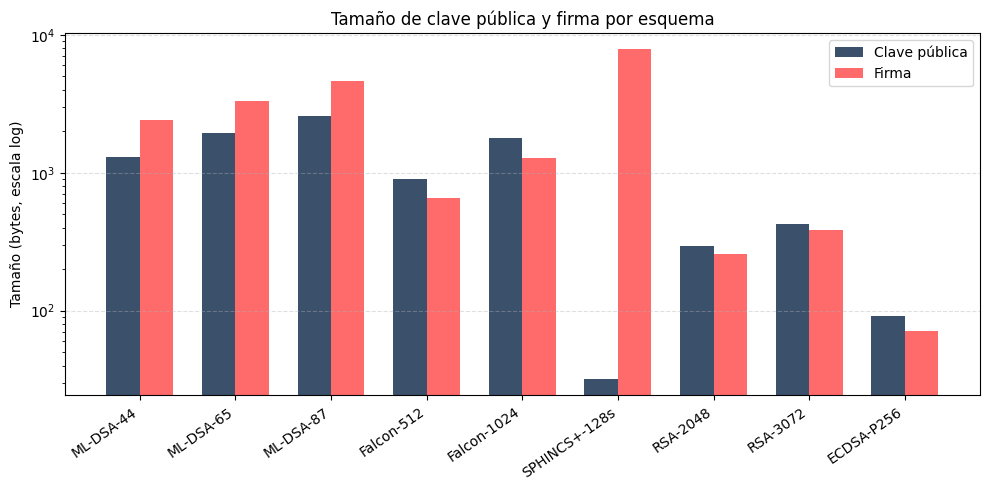

In [ ]:
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, pk_sizes, width, label="Clave pública", color="#3A506B")
ax.bar(x + width/2, sig_sizes, width, label="Firma", color="#FF6B6B")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(schemes, rotation=35, ha="right")
ax.set_ylabel("Tamaño (bytes, escala log)")
ax.set_title("Tamaño de clave pública y firma por esquema")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


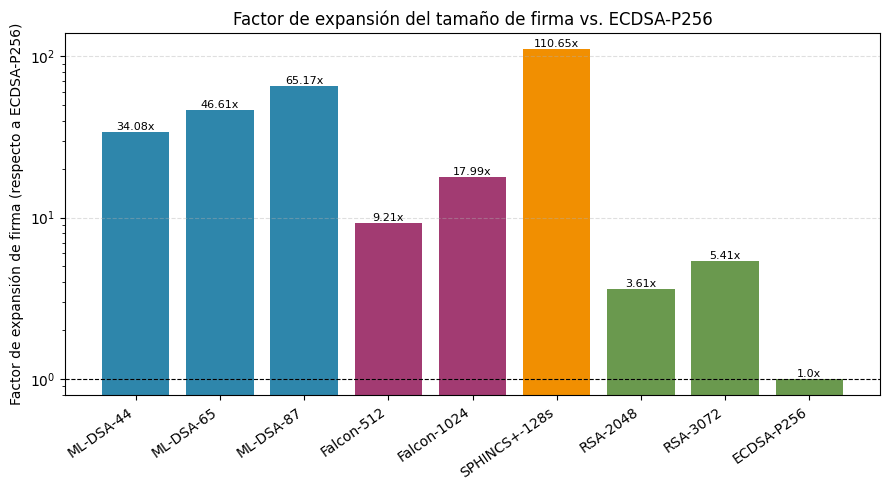

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(x, expansion_sig, color=colors)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(schemes, rotation=35, ha="right")
ax.set_ylabel("Factor de expansión de firma (respecto a ECDSA-P256)")
ax.set_title("Factor de expansión del tamaño de firma vs. ECDSA-P256")
ax.set_yscale("log")
for bar, val in zip(bars, expansion_sig):
    ax.text(bar.get_x() + bar.get_width()/2, val, f"{val}x", ha="center", va="bottom", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


---
## 3. Experimento 3: Caso de Uso — Distribución de Software Firmado

**Pregunta de investigación:** ¿Cómo se comporta cada esquema en un escenario realista de
firma de múltiples archivos (firma individual vs. firma de un manifiesto único)? ¿Qué tan
sensible es la verificación ante la corrupción de la firma?

**Diseño:** Se simula un "release" de N_FILES archivos de FILE_SIZE bytes cada uno.
Se compara (a) firmar cada archivo por separado vs. (b) firmar el hash concatenado de
todos los archivos (manifiesto). Adicionalmente, se mide la tasa de detección de
corrupción al alterar entre 1 y 3 bits de una firma válida.

**Nota:** por el alto costo de SPHINCS+, se usa una escala moderada (N_FILES=10, N_REPS=10)
para mantener el tiempo de ejecución razonable.


In [ ]:
N_FILES = 10
FILE_SIZE = 4096
N_REPS = 10


def make_fake_release(n_files=N_FILES, size=FILE_SIZE):
    return [os.urandom(size) for _ in range(n_files)]


class PQCScheme:
    def __init__(self, name, mod):
        self.name = name
        self.mod = mod
        self.pk, self.sk = mod.generate_keypair()

    def sign(self, msg):
        return self.mod.sign(self.sk, msg)

    def verify(self, msg, sig):
        return self.mod.verify(self.pk, msg, sig)


class ECDSAScheme:
    def __init__(self):
        self.name = "ECDSA-P256"
        self.priv = ec.generate_private_key(ec.SECP256R1())
        self.pub = self.priv.public_key()

    def sign(self, msg):
        return self.priv.sign(msg, ec.ECDSA(hashes.SHA256()))

    def verify(self, msg, sig):
        self.pub.verify(sig, msg, ec.ECDSA(hashes.SHA256()))
        return True


In [ ]:
def bench_pipeline(scheme, files):
    """(a) Firma individual: firma y verifica cada archivo por separado."""
    t0 = time.perf_counter()
    sigs = [scheme.sign(f) for f in files]
    t1 = time.perf_counter()
    for f, s in zip(files, sigs):
        assert scheme.verify(f, s)
    t2 = time.perf_counter()
    return {
        "sign_total_ms": (t1 - t0) * 1000.0,
        "verify_total_ms": (t2 - t1) * 1000.0,
        "n_signatures": len(files),
        "total_signature_bytes": sum(len(s) for s in sigs),
    }


def bench_manifest(scheme, files):
    """(b) Firma de manifiesto: se firma solo el hash concatenado de todos los archivos."""
    t0 = time.perf_counter()
    hashes_list = [hashlib.sha256(f).digest() for f in files]
    manifest = b"".join(hashes_list)
    sig = scheme.sign(manifest)
    t1 = time.perf_counter()
    hashes_list2 = [hashlib.sha256(f).digest() for f in files]
    manifest2 = b"".join(hashes_list2)
    ok = scheme.verify(manifest2, sig)
    t2 = time.perf_counter()
    assert ok
    return {
        "sign_total_ms": (t1 - t0) * 1000.0,
        "verify_total_ms": (t2 - t1) * 1000.0,
        "n_signatures": 1,
        "total_signature_bytes": len(sig),
    }


def repeat_bench(fn, scheme, n_reps):
    sign_times, verify_times = [], []
    sig_bytes = None
    for _ in range(n_reps):
        files = make_fake_release()
        r = fn(scheme, files)
        sign_times.append(r["sign_total_ms"])
        verify_times.append(r["verify_total_ms"])
        sig_bytes = r["total_signature_bytes"]
    return {
        "sign_total_ms_mean": round(st.mean(sign_times), 4),
        "sign_total_ms_stdev": round(st.stdev(sign_times), 4),
        "verify_total_ms_mean": round(st.mean(verify_times), 4),
        "verify_total_ms_stdev": round(st.stdev(verify_times), 4),
        "total_signature_bytes": sig_bytes,
    }


def corruption_sensitivity(scheme, n_trials=10, max_bits=3):
    """Para 1..max_bits bits corrompidos al azar en la firma, verifica si la verificación falla."""
    results = {}
    for n_bits in range(1, max_bits + 1):
        failures = 0
        for _ in range(n_trials):
            msg = os.urandom(256)
            sig = bytearray(scheme.sign(msg))
            positions = random.sample(range(len(sig) * 8), n_bits)
            for pos in positions:
                byte_i, bit_i = divmod(pos, 8)
                sig[byte_i] ^= (1 << bit_i)
            try:
                ok = scheme.verify(msg, bytes(sig))
            except Exception:
                ok = False
            if not ok:
                failures += 1
        results[n_bits] = failures / n_trials
    return results


### Ejecución del Experimento 3

**Nota:** SPHINCS+-128s puede tardar varios minutos en esta celda

In [ ]:
SCHEME_FACTORY = {
    "ML-DSA-44": lambda: PQCScheme("ML-DSA-44", ml_dsa_44),
    "ML-DSA-87": lambda: PQCScheme("ML-DSA-87", ml_dsa_87),
    "Falcon-512": lambda: PQCScheme("Falcon-512", falcon_512),
    "SPHINCS+-128s": lambda: PQCScheme("SPHINCS+-128s", sphincs128s),
    "ECDSA-P256": lambda: ECDSAScheme(),
}

results_exp3 = {"n_files": N_FILES, "file_size_bytes": FILE_SIZE, "n_reps": N_REPS, "schemes": []}

for name, factory in SCHEME_FACTORY.items():
    sch = factory()
    print(f"Procesando {sch.name} ...")
    individual = repeat_bench(bench_pipeline, sch, N_REPS)
    manifest = repeat_bench(bench_manifest, sch, N_REPS)
    corruption = corruption_sensitivity(sch, n_trials=10, max_bits=3)

    results_exp3["schemes"].append({
        "scheme": sch.name,
        "individual_signing": individual,
        "manifest_signing": manifest,
        "corruption_detection_rate": corruption,
    })

with open("exp3_resultados.json", "w") as f:
    json.dump(results_exp3, f, indent=2)

print("\nListo. Resultados guardados en exp3_resultados.json")


Procesando ML-DSA-44 ...
Procesando ML-DSA-87 ...
Procesando Falcon-512 ...
Procesando SPHINCS+-128s ...
Procesando ECDSA-P256 ...

Listo. Resultados guardados en exp3_resultados.json


In [ ]:
print(f"{'Esquema':<15}{'Individual(ms)':>16}{'Manifiesto(ms)':>16}{'Speedup':>10}")
for s in results_exp3["schemes"]:
    i = s["individual_signing"]["sign_total_ms_mean"]
    m = s["manifest_signing"]["sign_total_ms_mean"]
    print(f"{s['scheme']:<15}{i:>16.3f}{m:>16.3f}{i/m:>10.2f}x")

print("\nDetección de corrupción (tasa 1.0 = 100% detectado):")
for s in results_exp3["schemes"]:
    print(f"  {s['scheme']}: {s['corruption_detection_rate']}")


Esquema          Individual(ms)  Manifiesto(ms)   Speedup
ML-DSA-44                19.667           1.527     12.88x
ML-DSA-87                95.805           3.033     31.59x
Falcon-512              173.879          16.514     10.53x
SPHINCS+-128s         15555.365        1516.568     10.26x
ECDSA-P256                0.662           0.241      2.75x

Detección de corrupción (tasa 1.0 = 100% detectado):
  ML-DSA-44: {1: 1.0, 2: 1.0, 3: 1.0}
  ML-DSA-87: {1: 1.0, 2: 1.0, 3: 1.0}
  Falcon-512: {1: 1.0, 2: 1.0, 3: 1.0}
  SPHINCS+-128s: {1: 1.0, 2: 1.0, 3: 1.0}
  ECDSA-P256: {1: 1.0, 2: 1.0, 3: 1.0}


### Gráfico del Experimento 3

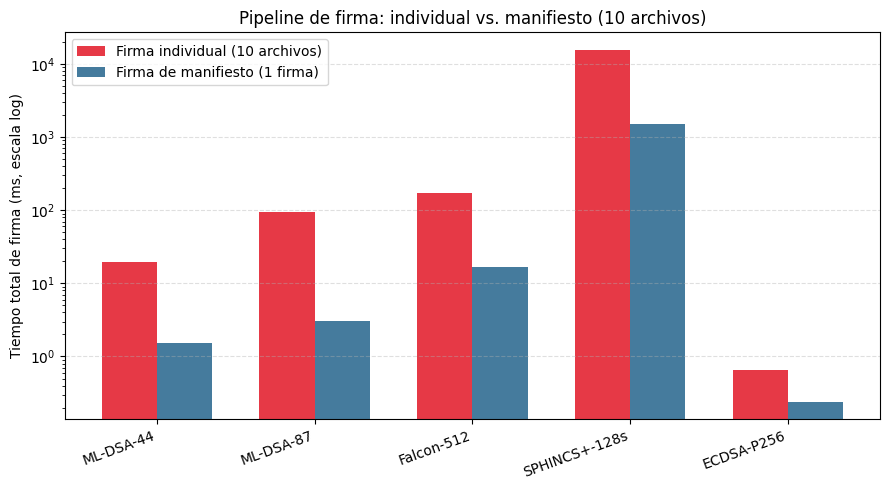

In [ ]:
order = ["ML-DSA-44", "ML-DSA-87", "Falcon-512", "SPHINCS+-128s", "ECDSA-P256"]
schemes_data = {s["scheme"]: s for s in results_exp3["schemes"]}
schemes3 = [s for s in order if s in schemes_data]

ind_sign = [schemes_data[s]["individual_signing"]["sign_total_ms_mean"] for s in schemes3]
man_sign = [schemes_data[s]["manifest_signing"]["sign_total_ms_mean"] for s in schemes3]

x3 = np.arange(len(schemes3))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x3 - width/2, ind_sign, width, label=f"Firma individual ({N_FILES} archivos)", color="#E63946")
ax.bar(x3 + width/2, man_sign, width, label="Firma de manifiesto (1 firma)", color="#457B9D")
ax.set_yscale("log")
ax.set_xticks(x3)
ax.set_xticklabels(schemes3, rotation=20, ha="right")
ax.set_ylabel("Tiempo total de firma (ms, escala log)")
ax.set_title(f"Pipeline de firma: individual vs. manifiesto ({N_FILES} archivos)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
